# Fitted extensions of the moment fields on the pancreas

In [1]:
%matplotlib inline
import matplotlib
_NB_BACKEND = matplotlib.get_backend()

import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PUBLIC = next((p for p in (_here, *_here.parents)
               if (p / "scripts").is_dir() and (p / "notebooks").is_dir()), None)
assert PUBLIC is not None, "run this from inside the repo's public/ tree"
sys.path.insert(0, str(PUBLIC))

import pandas as pd
import torch

from scripts.core.paths import figure_dir
from scripts.experiments.pancreas import extensions as ext
from scripts.experiments.pancreas import review as rv
from scripts.method import Run

matplotlib.use(_NB_BACKEND)
import matplotlib.pyplot as plt

pd.set_option("display.width", 220)
print(f"torch {torch.__version__}   cuda {torch.cuda.is_available()}")

torch 2.4.0+cu124   cuda True


## Constants and the tuned point

In [2]:
cfg = Run.from_env()

TUNED = {
    2: {
        'ffm': {'rho_mult': 1.000000e-01, 'lam_mult': 1.000000e-01},
        'mfm_land': {'land_rho': 3.160000e-04},
        'curly': {'curly_alpha': 1.000000e-01},
        'cfm': {},
    },
    10: {
        'ffm': {'rho_mult': 3.000000e-03, 'lam_mult': 3.000000e-01},
        'mfm_land': {'land_rho': 3.160000e-03},
        'curly': {'curly_alpha': 1.000000e-01},
        'cfm': {},
    },
}

_out = pathlib.Path(figure_dir(cfg.smoke))
_out.mkdir(exist_ok=True)
print(cfg)

device cuda   seeds (0, 1, 2)   smoke False   iters 2500/1500/1500


## The fits

In [3]:
FITS = {d: ext.fit(d, cfg, TUNED) for d in ext.DIMS}
rv.show(ext.frame_fit(FITS))

[scvelo_data] loading cache data/pancreas_cache/pancreas_d50_vw0.8_dynamical.npz


[scvelo_data] loading cache data/pancreas_cache/pancreas_d50_vw0.8_dynamical.npz


                            C error / size  b error / size  SV fraction    fit s
d  on the samples                                                               
2  FFM (shipped)                    0.2235          0.1973          NaN   0.5268
   FFM, log-Euclidean mean          0.2358          0.1973          NaN   0.1251
   FFM, SVR extension               0.4669          0.4640       0.8752   1.3225
   FFM, MLP extension               0.4884          0.4182          NaN   7.2003
   FFM, MLP + input noise           0.5078          0.4648          NaN   6.7604
10 FFM (shipped)                    0.7848          0.8138          NaN   0.0083
   FFM, log-Euclidean mean          0.8759          0.8138          NaN   0.0549
   FFM, SVR extension               0.8334          0.5272       0.8758  16.5732
   FFM, MLP extension               0.6699          0.4547          NaN   6.1155
   FFM, MLP + input noise           0.7988          0.7973          NaN   6.7602


## Travel cost at $d = 2$

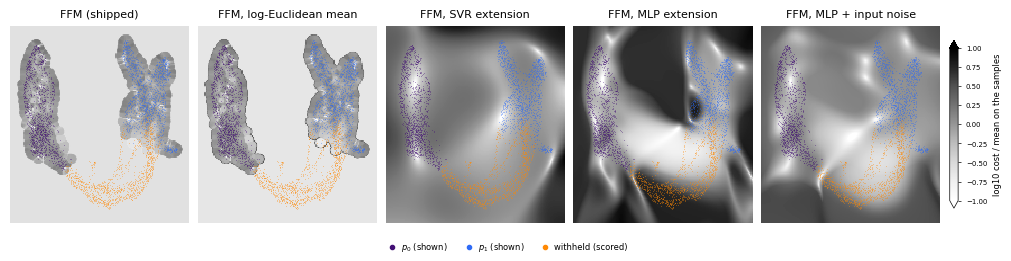

In [4]:
fig = ext.figure_cost(FITS[2], cfg, str(_out / "pancreas_extensions_cost"))

## The runs

In [5]:
EXT = ext.ensure(cfg, TUNED)
print(ext.header(EXT))

268/268 runs, 10 support records, Tesla V100-SXM2-32GB


In [6]:
rv.show(ext.frame_support(EXT))

                            void chord  void scored  cost void / data  cost scored / data  max |beta|
d  support                                                                                           
2  FFM (shipped)                0.6077       0.8076            0.2634              0.3205      0.9966
   FFM, log-Euclidean mean      0.6077       0.8076            0.2628              0.3121      0.9976
   FFM, SVR extension           0.6077       0.8076            1.1314              1.2661      0.9989
   FFM, MLP extension           0.6077       0.8076            3.5589              2.3581      0.9996
   FFM, MLP + input noise       0.6077       0.8076            0.8648              0.8550      0.9971
10 FFM (shipped)                0.0000       0.1160               NaN              1.0540      0.9813
   FFM, log-Euclidean mean      0.0000       0.1160               NaN              2.4628      0.9963
   FFM, SVR extension           0.0000       0.1160               NaN             

In [7]:
rv.show(rv.frame_seeds(EXT), rv.frame_chaos(EXT), rv.frame_arms(EXT))

                            n    mean      sd    q2.5  median   q97.5  seeds 0-2  pct among 3-seed means  P(FFM run wins)
d = 2 seed pool                                                                                                          
FFM (shipped)            32.0  1.4541  0.2146  1.0384  1.5200  1.7633     1.6692                 98.2056              NaN
OT-CFM                   20.0  1.8107  0.0296  1.7595  1.8103  1.8591     1.8062                 38.7719           0.9859
MFM / LAND               20.0  1.4811  0.0340  1.4076  1.4793  1.5293     1.4773                 34.8246           0.4484
Curly-FM                 20.0  1.0524  0.1015  0.8679  1.0338  1.2313     0.9773                  8.7719           0.0625
FFM, log-Euclidean mean  20.0  1.2782  0.2974  0.6529  1.3694  1.6383     1.3107                 54.1228           0.3141
FFM, SVR extension       20.0  1.5478  0.0797  1.4482  1.5544  1.7113     1.5436                 50.3509           0.5953
FFM, MLP extension      

## $W_2$ at $t = 1/2$ over seeds

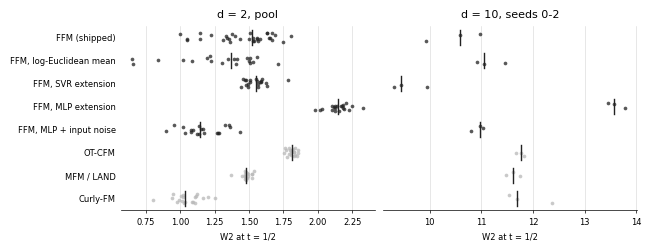

In [8]:
fig = ext.figure_pool(EXT, cfg, str(_out / "pancreas_extensions_pool"))

## The scored slice at $d = 2$

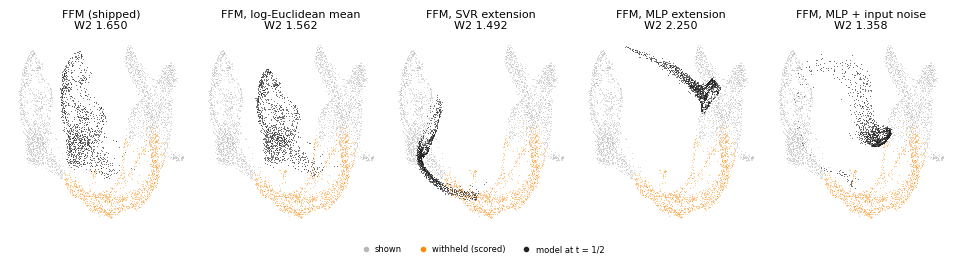

In [9]:
fig = ext.figure_mid(EXT, FITS[2], cfg, str(_out / "pancreas_extensions_mid"))